In [1]:
from IPython.display import display, HTML

display(HTML("""
<style>

/* =========================
   전체 레이아웃
========================= */

div.container{
    width:85% !important;
}

div.cell.code_cell.rendered{
    width:100%;
}

div.input_prompt{
    padding:0;
}

div.prompt{
    min-width:70px;
}

div#toc-wrapper{
    padding-top:120px;
}

table.dataframe{
    font-size:12px;
}

/* =========================
   코드 입력창
========================= */

div.CodeMirror{
    font-family:"마루 부리OTF 중간" !important;
    font-size:12pt !important;
    line-height:1.6;
}

/* =========================
   입력 셀
========================= */

div.input{
    font-family:"마루 부리OTF 중간" !important;
    font-size:12pt !important;
}

/* =========================
   코드 출력
========================= */

div.output{
    font-family:"마루 부리OTF 중간" !important;
    font-size:12pt !important;
}

/* =========================
   Markdown 전체
========================= */

.rendered_html{
    font-family:"마루 부리OTF 중간" !important;
    font-size:18px !important;
    line-height:1.8;
}

/* 제목 */

.rendered_html h1,
.rendered_html h2,
.rendered_html h3,
.rendered_html h4,
.rendered_html h5,
.rendered_html h6{
    font-family:"마루 부리OTF 조금굵은" !important;
}

/* 본문 */

.rendered_html p{
    font-family:"마루 부리OTF 중간" !important;
}

/* 리스트 */

.rendered_html li{
    font-family:"마루 부리OTF 중간" !important;
    padding:5px;
}

/* 인용 */

.rendered_html blockquote{
    font-family:"마루 부리OTF 중간" !important;
}

/* 표 */

.rendered_html table{
    font-family:"마루 부리OTF 중간" !important;
}

/* 코드 블록 */

.rendered_html pre,
.rendered_html code{
    font-family:"Consolas" !important;
    font-size:12pt !important;
}

</style>
"""))


# ※ Quiz : 경주여행과 전주여행에 대해 최빈단어시각화와 유사도분석
- (1) naver open API를 활용하여 블로그에 "경주여행", "전주여행"을 각각 500건씩 검색하여 백업
  (data/quiz/naver.csv)
     * 백업 파일 내용(query, no, title, link, description, total_text(title + ' ' + description)
- (2) naver.csv에서 total_text를 품사태깅(naver_pos.csv)
     * 파일 내용 : query, no, token, pos
- (3) 명사만 추출(naver_pos_nouns.csv)
     * query, token, pos
- (4) 빈도분석 백업(naver_pos_nouns_count.csv)
     * token, 경주빈도, 전주빈도, 빈도합
- (5) 빈도 시각화(워드클라우드, Text.plot)
     * 이미지 저장
- (6) 단어간 거리 분석(Word2Vec), 단어간 연관분석

# 1. 네이버 open API 활용하여 검색 추출
- query, no, title, link, description, total_text(title + ' ' + description)

In [2]:
# .env가져오기
from dotenv import load_dotenv
import os
load_dotenv()

True

In [3]:
# 네이버 개발자 센터에 있는 소스를 가져오기
# 네이버 검색 AIP 예제
# 방법 1 예시
import json
import os
import sys
import requests
import pandas as pd
import urllib.request
from dotenv import load_dotenv
from requests import get

client_id = os.getenv('CLIENT_ID')
client_secret = os.getenv('CLIENT_SECRET')
encText = urllib.parse.quote("경주 여행")
url = f"https://openapi.naver.com/v1/search/blog.json?query={encText}"# JSON 결과

request = urllib.request.Request(url)
request.add_header("X-Naver-Client-Id", client_id)
request.add_header("X-Naver-Client-Secret", client_secret)
response = urllib.request.urlopen(request)
rescode = response.getcode()

if(rescode==200):
    response_body = response.read()
    print(response_body.decode('utf-8')[:200])
else:
    print("Error Code:" + rescode)

{
	"lastBuildDate":"Fri, 04 Sep 2026 12:00:47 +0900",
	"total":2737522,
	"start":1,
	"display":10,
	"items":[
		{
			"title":"3월의 <b>경주여행<\/b>.",
			"link":"https:\/\/lje77777.tistory.com\/7132",
			"


In [4]:
# 문자 -> dict
import json
from html import unescape # description에 있는 &lt;(특수문자)를 <로 변경
import requests
import pandas as pd
import re # 특수문자 제거 !@#$%^&*()-=_+

In [5]:
query = "경주 여행"
start = 1
# url = f"https://openapi.naver.com/v1/search/blog.json?query={query}&display=100&start={start}"
url = "https://openapi.naver.com/v1/search/blog.json"
params = {
    'query':query,
    'display':100,
    'start':start
}
headers = {
    "X-Naver-Client-Id":client_id,
    "X-Naver-Client-Secret":client_secret
}
response = requests.get(url, headers=headers, params=params)

items = json.loads(response.text)['items']
itmes = response.json()['items']
items[4]

{'title': '경북 <b>경주여행</b>/불국사-단아함과 정숙함이 묻어나는 겹벚꽃(왕벚꽃)....',
 'link': 'https://skdywjd25.tistory.com/5973',
 'description': '벚꽃이 다 지고나면 피는 겹벗꽃 봄 <b>여행</b>을 즐기는 고수라면 서둘러 <b>경주</b>행 티켓을 예약하자. 또다시 <b>경주</b>가 들썩이고 있다.다 <b>경주</b>지역 벚꽃은 거의 떨어지고 불국사 쪽이 겹벚꽃으로 유명하다. 불국사 입구에... ',
 'bloggername': '산행과여행 사진으로 말한다',
 'bloggerlink': 'https://skdywjd25.tistory.com/',
 'postdate': '20190425'}

In [6]:
# title과 description의 <b>제거, html의 특수문자 제거, 일반특수 제거
item = items[4]
title = item['title'].replace('<b>', ' ').replace('</b>', ' ')
title = unescape(title)
title = re.sub(r'[^a-zA-Z0-9가-힣]', ' ', title)
description = item['description'].replace('<b>', ' ').replace('</b>', ' ')
description = unescape(description)
description = re.sub(r'[^a-zA-Z0-9가-힣]', '', description)
link = item['link']
total_text = title + ' ' + description
total_text

'경북  경주여행  불국사 단아함과 정숙함이 묻어나는 겹벚꽃 왕벚꽃      벚꽃이다지고나면피는겹벗꽃봄여행을즐기는고수라면서둘러경주행티켓을예약하자또다시경주가들썩이고있다다경주지역벚꽃은거의떨어지고불국사쪽이겹벚꽃으로유명하다불국사입구에'

In [7]:
# re 정규표현식을 이용해서 특수문자 제거
title = '[여행] ## & ktx 타고 짱 ㅋㅋ ㅠㅠ'
re.sub(r'[^a-zA-Z0-9가-힣]', ' ', title)

' 여행       ktx 타고 짱      '

In [8]:
# 네이버 API 정보 및 검색 정보
from dotenv import load_dotenv
import os
load_dotenv()
client_id = os.getenv('CLIENT_ID')
client_secret = os.getenv('CLIENT_SECRET')

In [9]:
def get_search_item_return(query, start):
    'query와 start로 naver 블로그 검색한 결과 title, link, descript, total_text를 dict list'
    'query, no, title, link, description, total_text(title + ' ' + description)'
    import requests
    # import json
    from html import unescape # html 특수문자 제거(ex. &nbsp; 제거)
    import os
    load_dotenv() # .env파일 읽어오기(환경변수 설정)
    
    client_id = os.getenv('CLIENT_ID')
    client_secret = os.getenv('CLIENT_SECRET')
    
    url = "https://openapi.naver.com/v1/search/blog.json"
    params = {
        'query':query,
        'display':100,
        'start':start
    }
    headers = {
        "X-Naver-Client-Id":client_id,
        "X-Naver-Client-Secret":client_secret
    }
    response = requests.get(url, headers=headers, params=params)

#     items = json.loads(response.text)['items']
    itmes = response.json()['items'] # 100개
    result = [] # items의 title, link, description등을 dict list로 append
    
    for i, item in enumerate(items):
        no = (start-1)*100 + i+1 # start가 1일때는 1,2,3, ... start가 2일때는 101, 102, ...
        
        title = item['title'].replace('<b>', ' ').replace('</b>', ' ')
        title = unescape(title)
        title = re.sub(r'[^a-zA-Z0-9가-힣]', ' ', title)
        
        link = item['link']
        
        description = item['description'].replace('<b>', ' ').replace('</b>', ' ')
        description = unescape(description)
        description = re.sub(r'[^a-zA-Z0-9가-힣]', ' ', description)
        
        total_text = title + ' ' + description
        
        #print(query, no, title[:5], link, description[:5], total_text[:5])
        result.append({
            'query' :query,
            'no' : no,
            'title' : title,
            'link' : link,
            'description' : description,
            'total_text' : total_text
        })
    return result

In [10]:
import time
queries = ['경주 여행', '전주 여행']
max_start = 5
result_total = []
for query in queries:
    for start in range(1, max_start+1):
        print(f'{query} 읽어오는 중...{start}/{max_start}')
        result_total.extend(get_search_item_return(query, start) )
        time.sleep(0.5)

경주 여행 읽어오는 중...1/5
경주 여행 읽어오는 중...2/5
경주 여행 읽어오는 중...3/5
경주 여행 읽어오는 중...4/5
경주 여행 읽어오는 중...5/5
전주 여행 읽어오는 중...1/5
전주 여행 읽어오는 중...2/5
전주 여행 읽어오는 중...3/5
전주 여행 읽어오는 중...4/5
전주 여행 읽어오는 중...5/5


In [11]:
import pandas as pd
df = pd.DataFrame(result_total)
print(df.shape)
df.sample(5)

(1000, 6)


,query,no,title,link,description,total_text
345,경주 여행,346,경주여행,https://cwh5513.tistory.com/203998,2020년 06월 13 14일 토 일요일 오전 비 오후 맑음 경주 에서 고향...,경주여행 2020년 06월 13 14일 토 일요일 오전 비 오후 맑음 경주...
863,전주 여행,364,경주여행 황남맷돌순두부 두부보쌈 제육 순두부찌개 그리고 호,https://jisuni-1116.tistory.com/336,경주 황남맷돌순두부 영업시간이 8시30분까지 경주 황리단길을 시작으로 어지...,경주여행 황남맷돌순두부 두부보쌈 제육 순두부찌개 그리고 호 ...
723,전주 여행,224,여행 이좋다 교리김밥 경주 맛집 경주여행 하면서 들린 김밥...,https://noproblemyourlife.tistory.com/226,경주 남산 등산을 포함해서 당일치기로 경주여행 을 계획하고 다녀왔습니다 그 ...,여행 이좋다 교리김밥 경주 맛집 경주여행 하면서 들린 김밥...
472,경주 여행,473,알라딘서재 역사 관심 갖기 시작해서 함께 읽었어요,https://blog.aladin.co.kr/735088274/14888282,갖길래 경주 여행 을 생각하고 있었는데 경주 를 그리는 마음을 접하게 됐어요 ...,알라딘서재 역사 관심 갖기 시작해서 함께 읽었어요 갖길래 경주 여행 을 생각하고...
690,전주 여행,191,경주 여행 불국사역 경주 역에서 동대구까지 기차 무궁화호 시간,https://okyoungi.tistory.com/50,경주 역은 시외 고속 버스터미널과 신 경주 역이 모두 거리가 있어서 어디로 여...,경주 여행 불국사역 경주 역에서 동대구까지 기차 무궁화호 시간 ...


In [12]:
df.to_csv('data/quiz_naver.csv', encoding='cp949', index=False)

# 2. 품사 태깅 백업
- query, no, token, pos -> quiz_naver_pos.csv백업

In [13]:
df = pd.read_csv('data/quiz_naver.csv', encoding='cp949')
df.head(1)

,query,no,title,link,description,total_text
0,경주 여행,1,경주여행 동궁과월지 첨성대 야경 연꽃단지 분황사,https://green54.tistory.com/1244,경주여행 때 방문했던 곳들을 다시 한번 남겨보려함 경주여행 경주 밤...,경주여행 동궁과월지 첨성대 야경 연꽃단지 분황사 경주여행 때 방문했던 ...


In [14]:
df[['query', 'no', 'total_text']]

,query,no,total_text
0,경주 여행,1,경주여행 동궁과월지 첨성대 야경 연꽃단지 분황사 경주여행 때 방문했던 ...
1,경주 여행,2,경북 경주여행 천문 기상 관측대 첨성대 여행 일자 2016년 9월 7일...
2,경주 여행,3,경주여행 은 원데이 택시투어 감사합니다 D 구매하러가기 https smart...
3,경주 여행,4,설레임 패밀리 일상 오늘의 목적지는 경주 회사 제휴로 숙소를 저렴하게 예약하고 ...
4,경주 여행,5,경북 경주여행 불국사 단아함과 정숙함이 묻어나는 겹벚꽃 왕벚꽃 벚꽃이 ...
...,...,...,...
995,전주 여행,496,알라딘서재 100자평 일상이 고고학 나 혼자 경주 여행 일상이 고고학 ...
996,전주 여행,497,경주여행 1 경주 나정맛집 나정에가면 라면맛집 경주 에도 바다가 ...
997,전주 여행,498,가을 경주 여행 경주 도착 오늘은 작년 여름 경주여행 코스였던 서출지와...
998,전주 여행,499,알라딘서재 100자평 일상이 고고학 나 혼자 경주 여행 일상이 고고학 ...


In [17]:
df_list = df[['query','no','total_text']].values.tolist()
df_list[::500], len(df_list)

([['경주 여행',
   1,
   ' 경주여행   동궁과월지 첨성대 야경  연꽃단지  분황사  경주여행  때 방문했던 곳들을 다시 한번 남겨보려함     경주여행    경주 밤에가볼만한곳    이웃님들 잘 지내셨나요  지난주 일    blog naver com 예전  여행 사진을 보니  여행 을 떠나고싶어진다 '],
  ['전주 여행',
   1,
   ' 경주여행   동궁과월지 첨성대 야경  연꽃단지  분황사  경주여행  때 방문했던 곳들을 다시 한번 남겨보려함     경주여행    경주 밤에가볼만한곳    이웃님들 잘 지내셨나요  지난주 일    blog naver com 예전  여행 사진을 보니  여행 을 떠나고싶어진다 ']],
 1000)

In [18]:
stopwords = ['전주', '여행', '경주']
'전주' not in stopwords

False

In [19]:
from konlpy.tag import Hannanum, Kkma, Komoran, Okt
from mecab import MeCab
analyzer = MeCab()
postagged_list = [] # 품사태깅한 dict list (query, no, token, pos)
stopwords = ['전주', '여행', '경주']
for i, row in enumerate(df_list):
    if i%250==0:
        print(f'총 1000번중 현재 {i}번째 품사태깅중')
    query = row[0]
    no    = row[1]
    total_text = row[2]
    tagged_list = analyzer.pos(total_text)
    for token, tag in tagged_list:
        if token not in stopwords and len(token)>1 : #2글자 이상의 stopword가 아닌 token
            postagged_list.append({'query':query,
                                  'no':no,
                                  'token':token,
                                  'pos':tag})

총 1000번중 현재 0번째 품사태깅중
총 1000번중 현재 250번째 품사태깅중
총 1000번중 현재 500번째 품사태깅중
총 1000번중 현재 750번째 품사태깅중


In [20]:
df_postagged = pd.DataFrame(postagged_list)
df_postagged.to_csv('data/quiz_naver_pos.csv', encoding='cp949', index=False)

# 3. 명사만 추출
- MeCab에서의 명사(NNG, NNP, NP)
- query, token, pos

In [21]:
df_postagged = pd.read_csv('data/quiz_naver_pos.csv', encoding='cp949')
select_pos = ['NNG', 'NNP', 'NP']
df_postagged.sample()

,query,no,token,pos
9595,경주 여행,379,시리즈,NNG


In [22]:
df_nouns = df_postagged.loc[df_postagged['pos'].isin(select_pos), ['query','token','pos']]
df_nouns.sample()

,query,token,pos
2773,경주 여행,준비,NNG


In [23]:
df_nouns.to_csv('data/quiz_naver_pos_noun.csv', encoding='cp949', index=False)

# 4. 빈도분석
- token, 경주빈도, 전주빈도, 빈도합, 경주비율, 전주비율

In [24]:
df_nouns.groupby(['query'], as_index=False)['pos'].count()

,query,pos
0,경주 여행,7980
1,전주 여행,7980


In [25]:
df_token_grp = df_nouns.groupby(['query', 'token'], as_index=False).count()
#df_token_grp.columns = ['query', 'token', 'count']
df_token_grp.rename(columns={'pos':'count'}, inplace=True)
df_token_grp.sample()

,query,token,count
994,전주 여행,시외,5


In [26]:
df_gj = df_token_grp.loc[df_token_grp['query']=='경주 여행', ['token','count']]
df_jj = df_token_grp.loc[df_token_grp['query']=='전주 여행', ['token','count']]
df_gj.shape, df_jj.shape

((653, 2), (653, 2))

In [27]:
df_gj.head(2)

,token,count
0,가격,10
1,가능,10


In [28]:
df_jj.head(2)

,token,count
653,가격,10
654,가능,10


In [29]:
# 두 데이터 프레임 병합
a = pd.DataFrame([{'token':'첨성대', 'count':10 },
                  {'token':'휴가', 'count':10 }])
b = pd.DataFrame([['휴가', 20],
                  ['한옥', 30]], columns=['token','count'])
display(a)
display(b)
ab = pd.merge(a, b,
             on = 'token', # 두 프레임을 병합할 기준 열이름
             how='outer' # inner, left, right
             )
ab

,token,count
0,첨성대,10
1,휴가,10


,token,count
0,휴가,20
1,한옥,30


,token,count_x,count_y
0,첨성대,10.0,NaN
1,휴가,10.0,20.0
2,한옥,NaN,30.0


In [31]:
df_mrg = pd.merge(df_gj, df_jj, on='token', how='outer')
df_mrg = df_mrg.fillna(0)
df_mrg = df_mrg.rename(columns={'count_x':'경주빈도', 'count_y':'전주빈도'})

In [34]:
import numpy as np
df_mrg['경주빈도'] = df_mrg['경주빈도'].astype(np.int16)
df_mrg['전주빈도'] = df_mrg['전주빈도'].astype(np.int16)
df_mrg['빈도합'] = df_mrg['경주빈도'] + df_mrg['전주빈도']
df_mrg = df_mrg.sort_values(by='빈도합', ascending=False)
df_mrg.head()

,token,경주빈도,전주빈도,빈도합
32,고고학,290,290,580
452,일상,290,290,580
362,알라딘,135,135,270
471,자평,110,110,220
22,경북,100,100,200


In [36]:
df_mrg['경주비율'] = round(df_mrg['경주빈도']/df_mrg['빈도합']*100, 1)
df_mrg['전주비율'] = round(df_mrg['전주빈도']/df_mrg['빈도합']*100, 1)
df_mrg.to_csv('data/quiz_naver_nouns_count.csv', index=False, encoding='cp949')

In [37]:
df_mrg.shape

(653, 6)

# 5. 빈도 시각화(워드클라우드, Text)

In [38]:
df_nouns = pd.read_csv('data/quiz_naver_pos_noun.csv', encoding='cp949')
df_nouns.shape
df_gj = df_token_grp.loc[df_token_grp['query']=='경주 여행', ['token','count']]
df_jj = df_token_grp.loc[df_token_grp['query']=='전주 여행', ['token','count']]

(15960, 3)

In [57]:
# 경주 명사들만 워드클라우드(data/heart.jpg 이용)
# 전주 명사들만 워드클라우드(data/korea-house-black-fill.png 이용)
gj_noun = df_nouns.loc[df_nouns['query']=='경주 여행','token'].values.tolist()
jj_noun = df_nouns.loc[df_nouns['query']=='전주 여행','token'].tolist() # 시리즈를 리스트로
gj = ' '.join(gj_noun)
jj = ' '.join(jj_noun)
print(gj[:10])
print(jj[:10])

동궁 월지 첨성대 



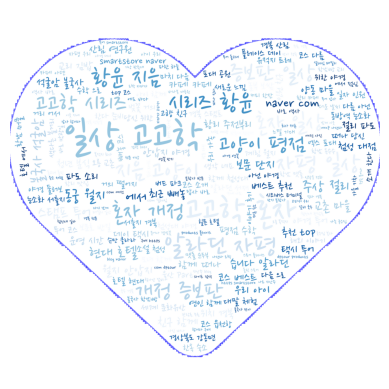

In [58]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
# import numpy as np
# from PIL import Image
# mask = np.array(Image.open('data/heart.jpg'))
import cv2
mask = cv2.imread('data/heart.jpg')
불용어 = set(['여행'])
wordcloud = WordCloud(
    background_color='white',
    colormap="Blues",
    collocations=True, # 특정단어가 자주 같이 나오면 같이 뿌려 ex황리단같은거는 같이
    max_words=200,
    max_font_size=200,
    scale=2, # 이미지 크기의 비율(다운로드시 달라짐)
    random_state=7,
    font_path = 'data/NanumPenScript-Regular.ttf',
    stopwords=불용어,
    mask = mask,
    contour_color='blue',
    contour_width=1
)
wordcloud.generate(gj)
plt.imshow(wordcloud)
plt.axis('off')
plt.show()

In [59]:
# 생성된 wordcloud 저장
wordcloud.to_file('data/quiz_naver_경주.jpg')

In [61]:
import numpy as np
from PIL import Image
mask = np.array(Image.open('data/korea-house-black-fill.png'))
# import cv2
# mask = cv2.imread('data/korea-house-black-fill.png')
wordcloud = WordCloud(
    background_color='white',
    colormap="Blues",
    collocations=True, # 특정단어가 자주 같이 나오면 같이 뿌려 ex황리단같은거는 같이
    max_words=200,
    max_font_size=200,
    scale=2, # 이미지 크기의 비율(다운로드시 달라짐)
    random_state=7,
    font_path = 'data/NanumPenScript-Regular.ttf',
    stopwords=불용어,
    mask = mask,
    contour_color='blue',
    contour_width=1
)
wordcloud.generate(jj)
plt.imshow(wordcloud)
plt.axis('off')
plt.show()

ValueError: We need at least 1 word to plot a word cloud, got 0.

In [62]:
# 생성된 wordcloud 저장
wordcloud.to_file('data/quiz_naver_전주.jpg')

ValueError: WordCloud has not been calculated, call generate first.

In [63]:
# 경주 명사들 Text plot
# 전주 명사들만 Text plot
print(gj_noun[:5])
print(jj_noun[:5])

['동궁', '월지', '첨성대', '야경', '연꽃']
[]


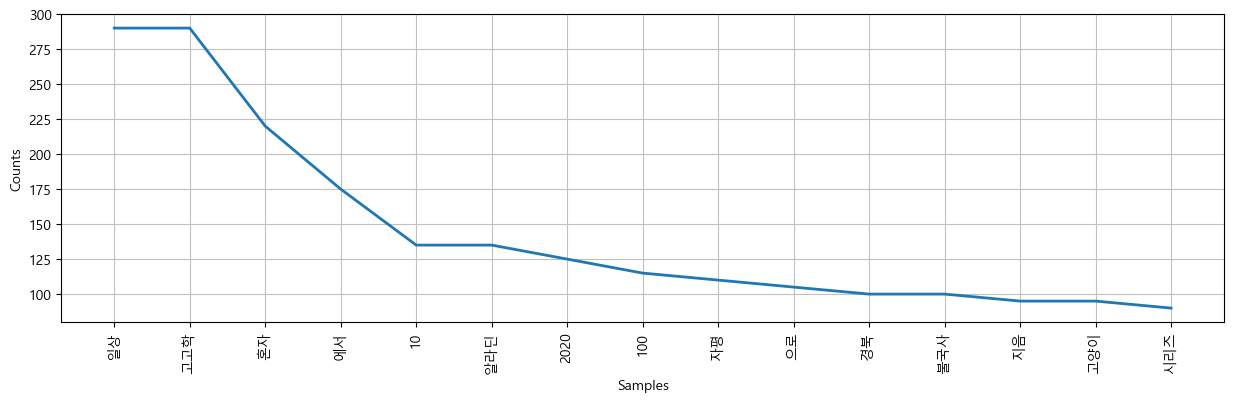

In [64]:
import nltk
import matplotlib.pyplot as plt
gj_text = nltk.Text(gj_noun)
plt.figure(figsize=(15,4))
plt.rc('font', family='Malgun Gothic')
gj_text.plot(15)
plt.show()

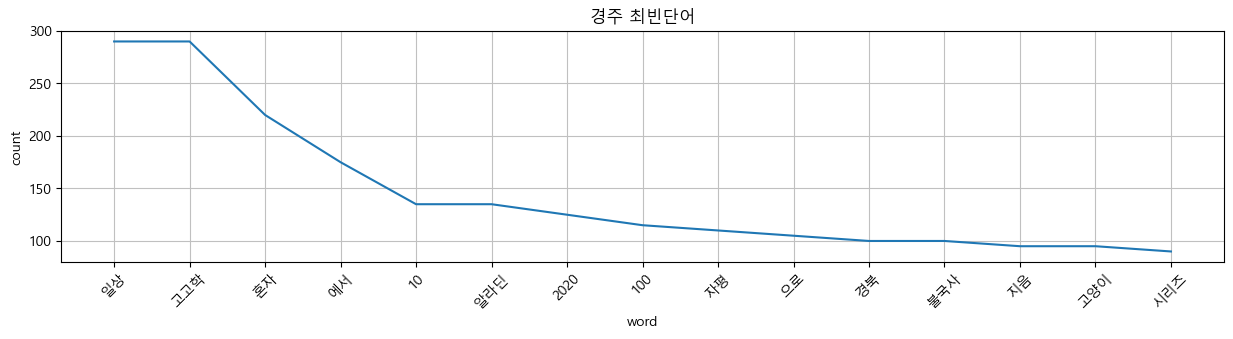

In [65]:
gj_word_counts = gj_text.vocab().most_common(15)
word   = [token for token, count in gj_word_counts]
counts = [count for token, count in gj_word_counts]
plt.figure(figsize=(15,3))
plt.plot(word, counts)
plt.xticks(rotation=45)
plt.xlabel('word')
plt.ylabel('count')
plt.title('경주 최빈단어')
plt.grid(True, color='silver') 
plt.show()

In [ ]:
jj_text = nltk.Text(jj_noun)
plt.figure(figsize=(15,4))
plt.rc('font', family='Malgun Gothic')
jj_text.plot(15)
plt.show()

In [ ]:
jj_word_counts = data_text.vocab().most_common(15)
word   = [token for token, count in jj_word_counts]
counts = [count for token, count in jj_word_counts]
plt.figure(figsize=(15,3))
plt.plot(word, counts)
plt.xticks(rotation=45)
plt.xlabel('word')
plt.ylabel('count')
plt.title('전주 최빈단어')
plt.grid(True, color='silver') 
plt.show()

# 6. 워드 임베딩
- Word@Vec

In [67]:
df = pd.read_csv('data/quiz_naver.csv', encoding='cp949')

In [66]:
total_text_list = df['total_text'].values.tolist()
# total_text_list = df['total_text'].to_list() 시리즈를 list로
total_text_list[-2:]

[' 알라딘서재  100자평  일상이 고고학  나 혼자  경주 여행  일상이 고고학  나 혼자  경주 여행    개정증보판  일상이 고고학 시리즈 2 황윤 지음   책읽는고양이   2020년 10월 평점   수학 여행  때는 역사의 의미를 모르고 지나쳤지만 이제는 작은 풍경 하나하나에서    ',
 ' 알라딘서재  100자평  일상이 고고학  나 혼자  경주 여행  앞서  출간된 일상이 고고학  나혼자 백제  여행  에 이어 이번엔  경주 여행 입니다  전작인 백제  여행 이 만족 스러웠던 분들이라면 이번  경주 여행 에도 무조건 탑승 하시길 바랍니다 ']

In [68]:
select_pos = ['NNP', 'NNG'] # Komoran, Kkma, MeCab의 일반명사, 고유명사
# select_pos = ['Noun'] # Okt의 일반명사, 고유명사
# select_pos = ['NC', 'NQ']# Hannanum의 보통명사, 고유명사
불용어 = {'여행'}

In [69]:
%%time
from konlpy.tag import Komoran, Kkma, Hannanum, Okt
from mecab import MeCab
analyzer = MeCab()
total_noun_list = []
for total_text in total_text_list:
    noun_list = [word for word, tag in analyzer.pos(total_text) 
                     if tag in select_pos and 
                             len(word)>1 and
                             word not in 불용어] # 명사, 2글자이상, 불용어제외
    total_noun_list.append(noun_list)

CPU times: total: 953 ms
Wall time: 971 ms


In [70]:
print(total_noun_list[-2:])

[['알라딘', '자평', '일상', '고고학', '경주', '일상', '고고학', '경주', '개정', '증보판', '일상', '고고학', '시리즈', '황윤', '지음', '고양이', '평점', '수학', '역사', '의미', '이제', '풍경'], ['알라딘', '자평', '일상', '고고학', '경주', '출간', '일상', '고고학', '혼자', '백제', '이번', '경주', '전작', '백제', '만족', '이번', '경주', '탑승']]


In [71]:
from gensim.models import Word2Vec
model = Word2Vec(total_noun_list,
                window=15,
                min_count=20,
                workers=1,
                sg=1)

In [72]:
print(model.wv.index_to_key)
print(len(model.wv))

['경주', '고고학', '일상', '알라딘', '자평', '불국사', '경북', '고양이', '지음', '평점', '황윤', '시리즈', '증보판', '개정', '첨성대', '황리', '역사', '코스', '야경', '투어', '호텔', '신라', '대릉원', '이야기', '석굴암', '카페', '시간', '가을', '맛집', '마을', '보문', '월지', '주상', '한옥', '수학', '생각', '안압지', '벚꽃', '오늘', '동궁', '스탬프', '황남', '절리', '점심', '버스', '기차', '아이', '시작', '위치', '교촌', '날씨', '순두부', '하늘', '추천', '현대', '혼자', '유적지', '행복', '커피', '이번', '주차장', '느낌', '거리', '운영', '정교', '가족', '도착', '숙소', '택시', '전화', '사진', '방문', '주차', '구경', '서울', '서출지', '석빙고', '김밥', '천마총', '국내', '울산', '후기', '사람', '풍경', '친구', '바다', '나정', '한잔', '답사', '맷돌', '단풍', '분식', '청년', '주전부리', '눈길', '마지막', '주문', '기대', '아덴', '베스트', '터미널', '다음', '오릉', '시외버스', '연구원', '산림', '마음', '저녁', '보쌈', '남산', '교리', '소리', '파도', '읍천항', '계림', '대점', '첨성', '소설', '산책', '분위기', '박물관', '입장료', '파크', '주변', '장소', '경상북도', '양동', '소개', '최근', '힐링', '보문호', '데이', '일자', '분황사', '백제', '에도', '코로나', '숲길', '자연', '토함산', '이상', '통일전', '옆집', '후배', '황남빵', '산수유', '압지', '나무', '힐튼', '학교', '박광일', '촬영', '월드', '울주', '순두부찌개', '두부', '마무리', '언니', '옥수수', 

In [73]:
model.wv.most_similar('전주')

KeyError: "Key '전주' not present in vocabulary"

In [74]:
model.wv.most_similar('경주')

[('이야기', 0.4975654184818268),
 ('백제', 0.49640578031539917),
 ('고향', 0.4919946789741516),
 ('이번', 0.4812208414077759),
 ('의미', 0.47958099842071533),
 ('강릉', 0.4762159585952759),
 ('하늘', 0.473618745803833),
 ('신라', 0.4733426570892334),
 ('시각', 0.4668971598148346),
 ('관심', 0.4631059765815735)]

In [75]:
# 유사한 단어 출력
print("입력된 단어와 유사한 단어 10개를 출력합니다.")
key = input()
if key in model.wv:
    print("{}와 유사한 단어:".format(key))
    print(model.wv.most_similar(key, topn=10))
else:
    print("{} 단어가 훈련 데이터에 없음".format(key))

입력된 단어와 유사한 단어 10개를 출력합니다.

 단어가 훈련 데이터에 없음
